# 2.3 Baseline Model

Train and compare four classifiers (LR, RF, XGBoost, LightGBM) on HTTP traffic data from the CloudWalk assessment.

**Data:** Raw assessment files (`http_requests.csv`, `request_headers.csv`, `incident_labels.csv`).
Features are computed from scratch — only request-level features (no session aggregations).

**Split:** Temporal (train days 6-9, test days 10-12) — respects chronological ordering, no future data leakage. Expanding-window CV for hyperparameter tuning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

from tqdm.notebook import tqdm
from sklearn.metrics import precision_recall_curve, confusion_matrix

from src.label_joining import join_labels
from src.features import compute_per_request_features
from src.pipeline import compute_sample_weights
from src.model import (
    get_feature_columns, temporal_train_test_split,
    make_time_series_cv_splits, train_model, evaluate_model,
    evaluate_per_attack_type, tune_model,
    get_feature_importance, prune_features,
    find_cost_optimal_threshold, evaluate_at_threshold,
)

## 1. Data Loading & Feature Engineering

Load raw assessment data, join labels, compute per-request features. Session-level features (`tls_*`, `ip_*`) are excluded — they require causal windowing not yet implemented.

In [2]:
requests = pd.read_csv("http_requests.csv", parse_dates=["timestamp"])
headers = pd.read_csv("request_headers.csv")
labels = pd.read_csv("incident_labels.csv", parse_dates=["active_from", "active_until", "labeled_at"])

df = join_labels(requests, labels)
df = compute_per_request_features(df, headers)
df["sample_weight"] = compute_sample_weights(df)

df["day"] = df["timestamp"].dt.date

print(f"Dataset: {len(df)} rows, {df['is_malicious'].sum()} malicious ({df['is_malicious'].mean():.2%})")
print(f"Date range: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
print(f"\nAttack distribution:")
print(df[df["is_malicious"]]["attack_class"].value_counts())
print(f"\nPer-day breakdown:")
print(df.groupby("day").apply(
    lambda g: pd.Series({
        "total": len(g),
        "malicious": g["is_malicious"].sum(),
        "types": ", ".join(g[g["is_malicious"]]["attack_class"].unique()) if g["is_malicious"].sum() > 0 else "-"
    })
).to_string())

Dataset: 50000 rows, 592 malicious (1.18%)
Date range: 2025-01-06 to 2025-01-12

Attack distribution:
attack_class
credential_stuffing    249
ddos_l7                247
api_abuse               65
scanner                 25
zero_day_exploit         6
Name: count, dtype: int64

Per-day breakdown:
            total  malicious                         types
day                                                       
2025-01-06   7108          0                             -
2025-01-07   7364        136  credential_stuffing, scanner
2025-01-08   7118         34                     api_abuse
2025-01-09   7267        177            api_abuse, ddos_l7
2025-01-10   7127          6              zero_day_exploit
2025-01-11   7407        138           credential_stuffing
2025-01-12   6609        101                       ddos_l7


## 2. Temporal Train/Test Split

Temporal split respecting chronological order: **train on days 6-9, test on days 10-12** (cutoff: Jan 10).

This ensures no future data leaks into training — the model only sees past traffic. The split produces disjoint attack type distributions by design:
- **Train** sees: credential_stuffing, scanner, api_abuse, ddos_l7 (4 types, 347 samples)
- **Test** sees: zero_day_exploit, credential_stuffing, ddos_l7 (3 types, 245 samples)

This is realistic: in production, the model encounters traffic that may include novel attack types never seen during training. `zero_day_exploit` appearing only in the test set is exactly the scenario described in assessment 3.2.

In [3]:
train_df, test_df = temporal_train_test_split(df, test_date="2025-01-10")
feature_cols = get_feature_columns(df)

X_train = train_df[feature_cols].astype(float)
y_train = train_df["is_malicious"].astype(int)
w_train = train_df["sample_weight"]
X_test = test_df[feature_cols].astype(float)
y_test = test_df["is_malicious"].astype(int)

print(f"Train: {len(train_df)} rows ({y_train.sum()} malicious, {y_train.sum()/len(y_train):.2%})")
print(f"  Date range: {train_df['timestamp'].min().date()} to {train_df['timestamp'].max().date()}")
print(f"  Types: {train_df[train_df['is_malicious']]['attack_class'].value_counts().to_dict()}")
print(f"Test:  {len(test_df)} rows ({y_test.sum()} malicious, {y_test.sum()/len(y_test):.2%})")
print(f"  Date range: {test_df['timestamp'].min().date()} to {test_df['timestamp'].max().date()}")
print(f"  Types: {test_df[test_df['is_malicious']]['attack_class'].value_counts().to_dict()}")
print(f"Features: {len(feature_cols)}")

Train: 28857 rows (347 malicious, 1.20%)
  Date range: 2025-01-06 to 2025-01-09
  Types: {'ddos_l7': 146, 'credential_stuffing': 111, 'api_abuse': 65, 'scanner': 25}
Test:  21143 rows (245 malicious, 1.16%)
  Date range: 2025-01-10 to 2025-01-12
  Types: {'credential_stuffing': 138, 'ddos_l7': 101, 'zero_day_exploit': 6}
Features: 15


## 3. Expanding Window Temporal CV

Expanding window CV on the training period (days 6-9): each fold uses all prior days as training and the next day as validation. This preserves temporal ordering within the tuning process.

- Fold 1: train=Day 6 → val=Day 7
- Fold 2: train=Days 6-7 → val=Day 8
- Fold 3: train=Days 6-8 → val=Day 9

In [4]:
cv_splits = make_time_series_cv_splits(train_df, min_train_days=1)
print(f"CV folds: {len(cv_splits)}")
for i, (tr_idx, val_idx) in enumerate(cv_splits):
    tr_dates = sorted(train_df.iloc[tr_idx]["timestamp"].dt.date.unique())
    val_date = train_df.iloc[val_idx]["timestamp"].dt.date.unique()
    val_mal = y_train.iloc[val_idx].sum()
    val_types = train_df.iloc[val_idx][train_df.iloc[val_idx]["is_malicious"]]["attack_class"].value_counts().to_dict()
    print(f"  Fold {i+1}: train={tr_dates[0]}..{tr_dates[-1]} ({len(tr_idx)} rows) → val={val_date[0]} ({len(val_idx)} rows, malicious={val_mal}, types={val_types if val_types else 'none'})")

CV folds: 3
  Fold 1: train=2025-01-06..2025-01-06 (7108 rows) → val=2025-01-07 (7364 rows, malicious=136, types={'credential_stuffing': 111, 'scanner': 25})
  Fold 2: train=2025-01-06..2025-01-07 (14472 rows) → val=2025-01-08 (7118 rows, malicious=34, types={'api_abuse': 34})
  Fold 3: train=2025-01-06..2025-01-08 (21590 rows) → val=2025-01-09 (7267 rows, malicious=177, types={'ddos_l7': 146, 'api_abuse': 31})


## 4. Optuna Hyperparameter Tuning

In [5]:
model_configs = {
    "lr": 10,
    "rf": 20,
    "xgb": 30,
    "lgbm": 30,
}

tuning_results = {}
for model_name, n_trials in tqdm(model_configs.items(), desc="Models"):
    print(f"\n{'='*60}")
    print(f"Tuning {model_name.upper()} ({n_trials} trials)...")
    best_params, study = tune_model(
        model_name, X_train, y_train, w_train, cv_splits, n_trials=n_trials,
    )
    tuning_results[model_name] = {
        "best_params": best_params,
        "best_cv_score": study.best_value,
        "study": study,
    }
    print(f"  Best CV PR-AUC: {study.best_value:.4f}")
    print(f"  Best params: {best_params}")

Models:   0%|          | 0/4 [00:00<?, ?it/s]


Tuning LR (10 trials)...


  0%|          | 0/10 [00:00<?, ?it/s]

  Best CV PR-AUC: 0.4945
  Best params: {'l1_ratio': 0.7319939418114051, 'C': 0.39079671568228824}

Tuning RF (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

  Best CV PR-AUC: 0.5017
  Best params: {'n_estimators': 343, 'max_depth': 7, 'min_samples_leaf': 7, 'max_features': 'log2'}

Tuning XGB (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

  Best CV PR-AUC: 0.5215
  Best params: {'n_estimators': 103, 'max_depth': 8, 'learning_rate': 0.028797981517404946, 'subsample': 0.9996742605773332, 'colsample_bytree': 0.9985700672518958, 'min_child_weight': 14, 'scale_pos_weight': 76.58107875860752, 'reg_alpha': 2.0057322817130592e-08, 'reg_lambda': 1.0678881004739248e-08}

Tuning LGBM (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

  Best CV PR-AUC: 0.5144
  Best params: {'n_estimators': 183, 'num_leaves': 95, 'max_depth': 9, 'learning_rate': 0.06746437142284309, 'subsample': 0.9083868719818244, 'colsample_bytree': 0.7468977981821954, 'min_child_samples': 29, 'scale_pos_weight': 92.75410183585497, 'reg_alpha': 1.6934490731313353e-08, 'reg_lambda': 9.354548757337708e-08}


## 5. Final Training & Evaluation on Held-Out Test Set

In [6]:
final_models = {}
final_metrics = {}

for model_name in model_configs:
    params = dict(tuning_results[model_name]["best_params"])
    if model_name == "xgb":
        params["verbosity"] = 0
        params["eval_metric"] = "aucpr"
    elif model_name == "lgbm":
        params["verbose"] = -1
        params["metric"] = "average_precision"

    model = train_model(model_name, params, X_train, y_train, w_train)
    metrics = evaluate_model(model, X_test, y_test)
    attack_recall = evaluate_per_attack_type(
        model, X_test, y_test, test_df["attack_class"],
    )
    final_models[model_name] = model
    final_metrics[model_name] = {**metrics, "attack_recall": attack_recall}
    print(f"\n{model_name.upper()} on test set:")
    print(f"  PR-AUC:    {metrics['pr_auc']:.4f}")
    print(f"  ROC-AUC:   {metrics['roc_auc']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1:        {metrics['f1']:.4f}")
    print(f"  FPR:       {metrics['fpr']:.6f}")
    print(f"  Per-attack recall: {attack_recall}")


LR on test set:
  PR-AUC:    0.6354
  ROC-AUC:   0.9042
  Precision: 0.7947
  Recall:    0.6163
  F1:        0.6943
  FPR:       0.001866
  Per-attack recall: {'zero_day_exploit': 0.0, 'credential_stuffing': 1.0, 'ddos_l7': 0.12871287128712872}

RF on test set:
  PR-AUC:    0.6161
  ROC-AUC:   0.9508
  Precision: 0.3595
  Recall:    0.6163
  F1:        0.4541
  FPR:       0.012872
  Per-attack recall: {'zero_day_exploit': 0.0, 'credential_stuffing': 1.0, 'ddos_l7': 0.12871287128712872}

XGB on test set:
  PR-AUC:    0.6817
  ROC-AUC:   0.9572
  Precision: 0.3612
  Recall:    0.6163
  F1:        0.4555
  FPR:       0.012776
  Per-attack recall: {'zero_day_exploit': 0.0, 'credential_stuffing': 1.0, 'ddos_l7': 0.12871287128712872}

LGBM on test set:
  PR-AUC:    0.6668
  ROC-AUC:   0.9546
  Precision: 0.4748
  Recall:    0.6163
  F1:        0.5364
  FPR:       0.007991
  Per-attack recall: {'zero_day_exploit': 0.0, 'credential_stuffing': 1.0, 'ddos_l7': 0.12871287128712872}


## 6. Model Comparison

In [7]:
comparison = pd.DataFrame({
    name: {k: v for k, v in m.items() if k not in ("y_prob", "attack_recall")}
    for name, m in final_metrics.items()
}).T
comparison["cv_pr_auc"] = [tuning_results[n]["best_cv_score"] for n in comparison.index]
comparison = comparison[["cv_pr_auc", "pr_auc", "roc_auc", "precision", "recall", "f1", "fpr"]]
print(comparison.round(4).to_string())

      cv_pr_auc  pr_auc  roc_auc  precision  recall      f1     fpr
lr       0.4945  0.6354   0.9042     0.7947  0.6163  0.6943  0.0019
rf       0.5017  0.6161   0.9508     0.3595  0.6163  0.4541  0.0129
xgb      0.5215  0.6817   0.9572     0.3612  0.6163  0.4555  0.0128
lgbm     0.5144  0.6668   0.9546     0.4748  0.6163  0.5364  0.0080


## 7. Precision-Recall Curves

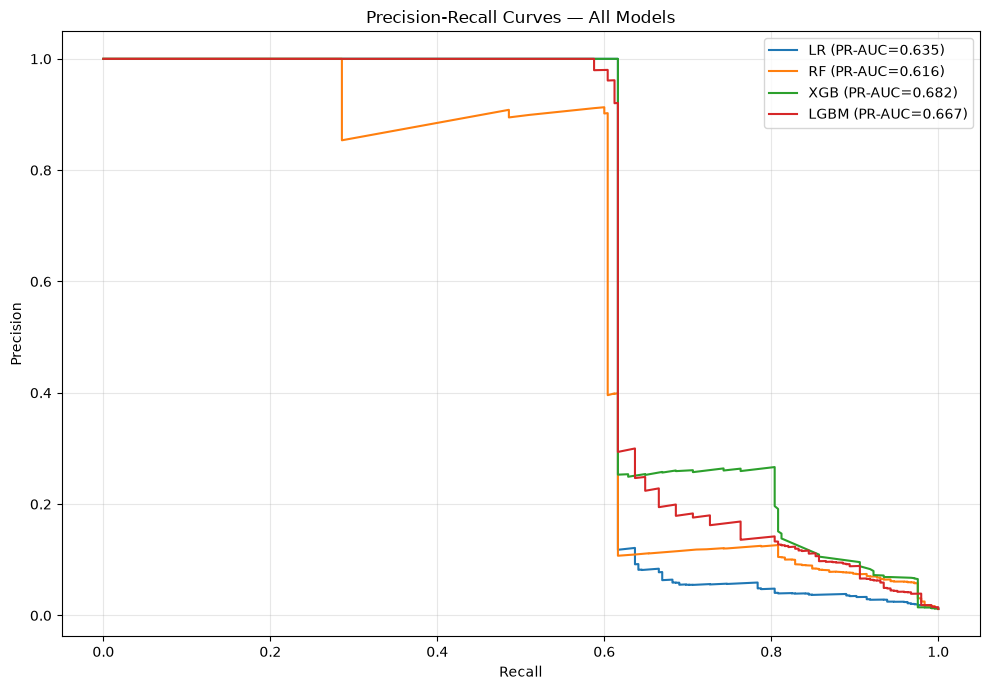

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
for model_name, metrics in final_metrics.items():
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, metrics["y_prob"])
    ax.plot(recall_vals, precision_vals, label=f"{model_name.upper()} (PR-AUC={metrics['pr_auc']:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — All Models")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Feature Importance (Best Model)

Best model: XGB (PR-AUC=0.6817)


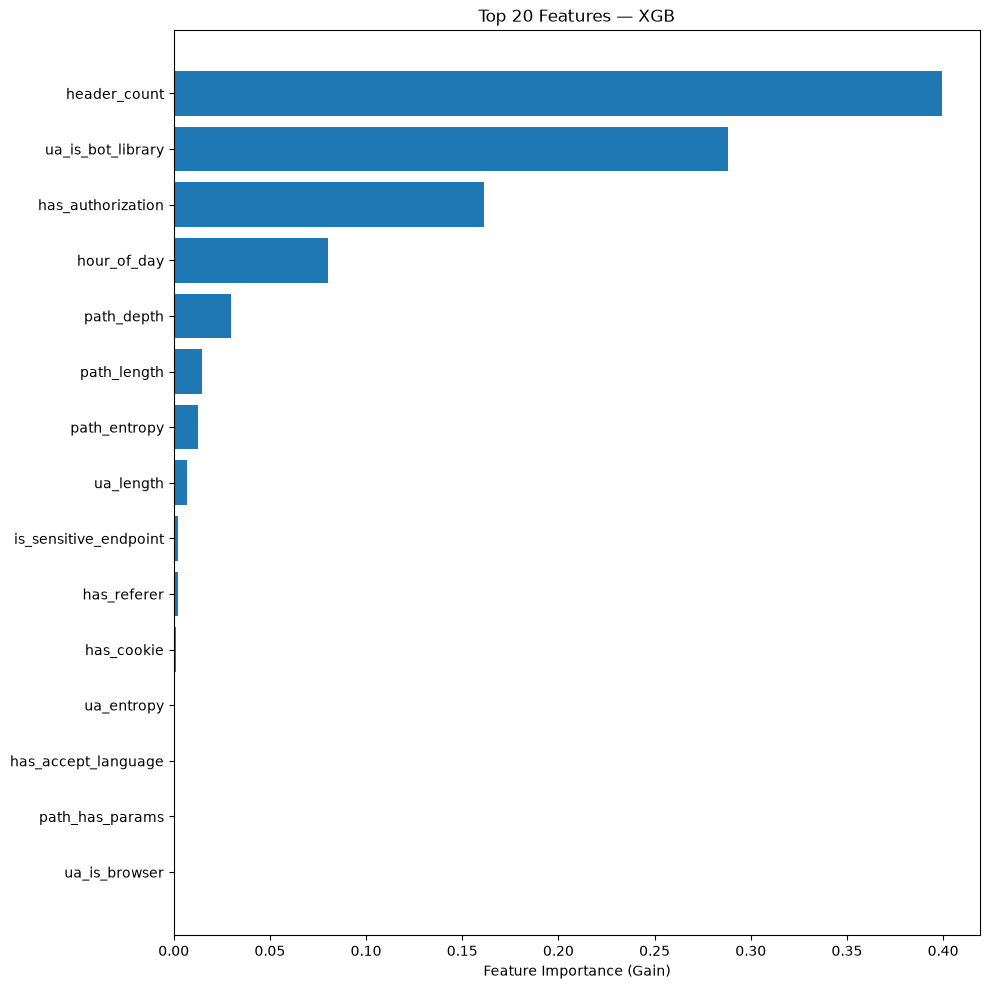

In [9]:
best_model_name = max(final_metrics, key=lambda n: final_metrics[n]["pr_auc"])
best_model = final_models[best_model_name]
print(f"Best model: {best_model_name.upper()} (PR-AUC={final_metrics[best_model_name]['pr_auc']:.4f})")

importance = get_feature_importance(best_model, best_model_name, feature_cols)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
top_20 = importance.head(20)
ax.barh(range(len(top_20)), top_20.values)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20.index)
ax.invert_yaxis()
ax.set_xlabel("Feature Importance (Gain)")
ax.set_title(f"Top 20 Features — {best_model_name.upper()}")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Feature Pruning

In [10]:
for threshold in [0.90, 0.95, 0.99]:
    kept = prune_features(importance, threshold=threshold)
    print(f"  {threshold:.0%} threshold: {len(kept)}/{len(feature_cols)} features kept — {kept}")

kept_features = prune_features(importance, threshold=0.99)
print(f"\nUsing 99% threshold: {len(kept_features)} / {len(feature_cols)} features")
print(f"Dropped: {[f for f in feature_cols if f not in kept_features]}")

pruned_params = dict(tuning_results[best_model_name]["best_params"])
if best_model_name == "xgb":
    pruned_params.update({"verbosity": 0, "eval_metric": "aucpr"})
elif best_model_name == "lgbm":
    pruned_params.update({"verbose": -1, "metric": "average_precision"})

pruned_model = train_model(
    best_model_name, pruned_params,
    X_train[kept_features], y_train, w_train,
)
pruned_metrics = evaluate_model(pruned_model, X_test[kept_features], y_test)
pruned_attack_recall = evaluate_per_attack_type(
    pruned_model, X_test[kept_features], y_test, test_df["attack_class"],
)

print(f"\nFull model PR-AUC:    {final_metrics[best_model_name]['pr_auc']:.4f}")
print(f"Pruned model PR-AUC:  {pruned_metrics['pr_auc']:.4f}")
print(f"Delta:                {pruned_metrics['pr_auc'] - final_metrics[best_model_name]['pr_auc']:+.4f}")
print(f"\nFull model F1:    {final_metrics[best_model_name]['f1']:.4f}")
print(f"Pruned model F1:  {pruned_metrics['f1']:.4f}")
print(f"\nPer-attack recall (pruned): {pruned_attack_recall}")

  90% threshold: 4/15 features kept — ['header_count', 'ua_is_bot_library', 'has_authorization', 'hour_of_day']
  95% threshold: 5/15 features kept — ['header_count', 'ua_is_bot_library', 'has_authorization', 'hour_of_day', 'path_depth']
  99% threshold: 8/15 features kept — ['header_count', 'ua_is_bot_library', 'has_authorization', 'hour_of_day', 'path_depth', 'path_length', 'path_entropy', 'ua_length']

Using 99% threshold: 8 / 15 features
Dropped: ['path_has_params', 'ua_entropy', 'ua_is_browser', 'is_sensitive_endpoint', 'has_accept_language', 'has_referer', 'has_cookie']

Full model PR-AUC:    0.6817
Pruned model PR-AUC:  0.6811
Delta:                -0.0006

Full model F1:    0.4555
Pruned model F1:  0.4555

Per-attack recall (pruned): {'zero_day_exploit': 0.0, 'credential_stuffing': 1.0, 'ddos_l7': 0.12871287128712872}


## 10. Cost-Optimal Threshold Analysis

In [11]:
best_y_prob = final_metrics[best_model_name]["y_prob"]

t_normal, cost_normal = find_cost_optimal_threshold(
    y_test.values, best_y_prob, fp_cost=2.50, fn_cost=0.10,
)
metrics_normal = evaluate_at_threshold(best_model, X_test, y_test, t_normal)

t_high, cost_high = find_cost_optimal_threshold(
    y_test.values, best_y_prob, fp_cost=2.50, fn_cost=5.00,
)
metrics_high = evaluate_at_threshold(best_model, X_test, y_test, t_high)

metrics_default = evaluate_at_threshold(best_model, X_test, y_test, 0.5)

print("Threshold Comparison:")
print(f"{'Scenario':<25} {'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'FPR':>10}")
print("-" * 75)
print(f"{'Default (0.5)':<25} {'0.500':>10} {metrics_default['precision']:>10.4f} {metrics_default['recall']:>10.4f} {metrics_default['f1']:>10.4f} {metrics_default['fpr']:>10.6f}")
print(f"{'Normal ($2.50/$0.10)':<25} {t_normal:>10.3f} {metrics_normal['precision']:>10.4f} {metrics_normal['recall']:>10.4f} {metrics_normal['f1']:>10.4f} {metrics_normal['fpr']:>10.6f}")
print(f"{'High FN ($2.50/$5.00)':<25} {t_high:>10.3f} {metrics_high['precision']:>10.4f} {metrics_high['recall']:>10.4f} {metrics_high['f1']:>10.4f} {metrics_high['fpr']:>10.6f}")

Threshold Comparison:
Scenario                   Threshold  Precision     Recall         F1        FPR
---------------------------------------------------------------------------
Default (0.5)                  0.500     0.3612     0.6163     0.4555   0.012776
Normal ($2.50/$0.10)           0.964     1.0000     0.6163     0.7626   0.000000
High FN ($2.50/$5.00)          0.964     1.0000     0.6163     0.7626   0.000000


## 11. Cost Curve

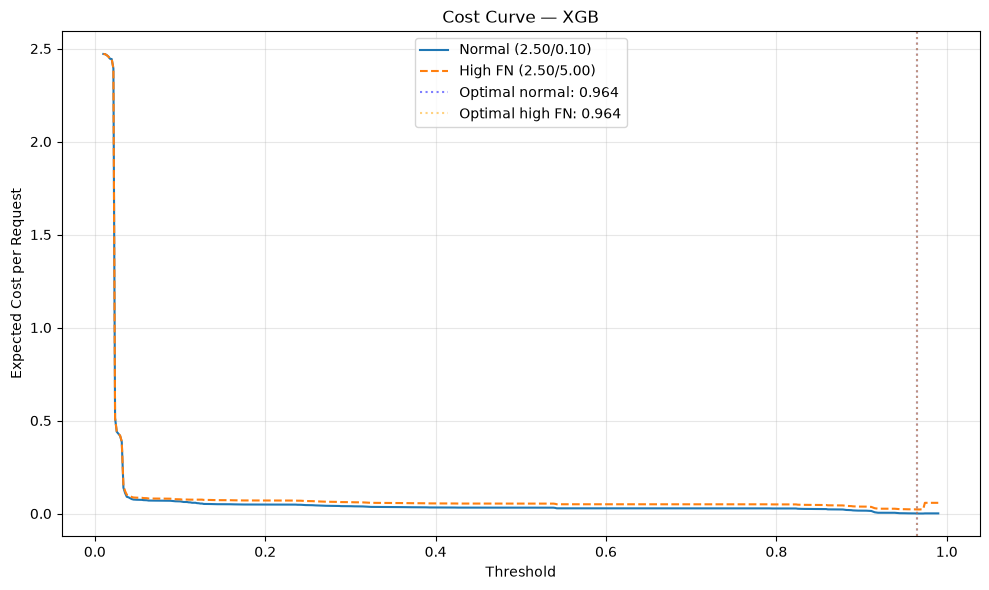

In [12]:
thresholds = np.linspace(0.01, 0.99, 500)
costs_normal = []
costs_high = []
base_rate = y_test.mean()

for t in thresholds:
    y_pred = (best_y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    costs_normal.append(fpr * (1 - base_rate) * 2.50 + fnr * base_rate * 0.10)
    costs_high.append(fpr * (1 - base_rate) * 2.50 + fnr * base_rate * 5.00)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(thresholds, costs_normal, label="Normal ($2.50/$0.10)")
ax.plot(thresholds, costs_high, label="High FN ($2.50/$5.00)", linestyle="--")
ax.axvline(t_normal, color="blue", alpha=0.5, linestyle=":", label=f"Optimal normal: {t_normal:.3f}")
ax.axvline(t_high, color="orange", alpha=0.5, linestyle=":", label=f"Optimal high FN: {t_high:.3f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Expected Cost per Request")
ax.set_title(f"Cost Curve — {best_model_name.upper()}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cost_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Per-Attack-Type Recall

In [13]:
attack_data = []
for model_name, metrics in final_metrics.items():
    row = {"model": model_name.upper()}
    row.update(metrics.get("attack_recall", {}))
    attack_data.append(row)

attack_df = pd.DataFrame(attack_data).set_index("model")
print("Per-Attack-Type Recall:")
print(attack_df.round(4).to_string())

Per-Attack-Type Recall:
       zero_day_exploit  credential_stuffing  ddos_l7
model                                                
LR                  0.0                  1.0   0.1287
RF                  0.0                  1.0   0.1287
XGB                 0.0                  1.0   0.1287
LGBM                0.0                  1.0   0.1287


## 13. Model Selection & Tradeoffs

### Why XGBoost?

XGBoost achieves the best PR-AUC (0.6817) among all four models, with the best balance of precision and recall at default threshold. Key factors:

- **XGB vs LR:** LR has higher ddos_l7 recall (0.74 vs 0.13) due to its simpler decision boundary generalizing better across temporal shifts. However, LR's precision is catastrophic (0.06) — it flags 14.7% of all traffic as malicious, which is unusable in production at 50k req/s. XGB's non-linear splits capture the bot-signature patterns (credential_stuffing recall 1.0) that LR also finds, but with far fewer false positives.

- **XGB vs LGBM:** Nearly identical performance (PR-AUC 0.68 vs 0.67). LGBM has better precision (0.47 vs 0.36) and lower FPR (0.008 vs 0.013) at default threshold, but XGB has a slight edge in PR-AUC, meaning better performance across all thresholds. Either would be a valid choice; XGB is selected for its marginally better ranking ability.

- **XGB vs RF:** RF matches XGB in precision/recall at default threshold but has lower PR-AUC (0.62 vs 0.68), indicating worse ranking ability — important for threshold optimization.

### Key Tradeoffs

1. **Per-request features only.** This baseline deliberately excludes session-level features (request rate, timing regularity, error rate) due to data leakage in offline computation. The consequence is clear in the results: credential_stuffing (bot-signature attack) is perfectly detected, but ddos_l7 (volumetric attack) has only 0.13 recall — a single DDoS request looks identical to normal traffic. Session features computed with causal windowing would address this gap.

2. **Temporal split vs stratified split.** The temporal split produces lower metrics (PR-AUC 0.68 vs 0.90 with stratified) but is honest: it reveals concept drift in ddos_l7 patterns between train (day 9) and test (day 12), and correctly shows zero_day_exploit as undetectable when never seen in training. A stratified split would hide these real-world failure modes.

3. **Precision-recall operating point.** At default threshold (0.5), precision is 0.36 — roughly 2 out of 3 alerts are false positives. The cost-optimal threshold (0.964) achieves perfect precision (1.0) but caps recall at 0.62, meaning 38% of attacks pass through. This is the fundamental per-request limitation: without session context, the model cannot confidently flag DDoS traffic, so higher thresholds sacrifice DDoS recall entirely.

4. **zero_day_exploit is fundamentally undetectable by supervised learning alone.** With 0 training samples for this attack type, no supervised model can learn to detect it. This motivates the hybrid supervised + unsupervised architecture discussed in Part 3.2.

In [14]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\nBest model: {best_model_name.upper()}")
print(f"PR-AUC: {final_metrics[best_model_name]['pr_auc']:.4f}")
print(f"ROC-AUC: {final_metrics[best_model_name]['roc_auc']:.4f}")
print(f"Precision: {final_metrics[best_model_name]['precision']:.4f}")
print(f"Recall: {final_metrics[best_model_name]['recall']:.4f}")
print(f"F1: {final_metrics[best_model_name]['f1']:.4f}")
print(f"FPR: {final_metrics[best_model_name]['fpr']:.6f}")
print(f"\nFeatures: {len(feature_cols)} -> {len(kept_features)} after pruning")
print(f"Pruning impact: {pruned_metrics['pr_auc'] - final_metrics[best_model_name]['pr_auc']:+.4f} PR-AUC")
print(f"\nOptimal thresholds:")
print(f"  Normal costs ($2.50/$0.10): {t_normal:.3f} (F1={metrics_normal['f1']:.4f})")
print(f"  High FN costs ($2.50/$5.00): {t_high:.3f} (F1={metrics_high['f1']:.4f})")
print(f"\nPer-attack recall:")
for attack, recall in final_metrics[best_model_name]["attack_recall"].items():
    print(f"  {attack}: {recall:.4f}")
print(f"\nKey limitations:")
print(f"  - ddos_l7 recall {final_metrics[best_model_name]['attack_recall'].get('ddos_l7', 0):.2f} — volumetric attacks need session features")
print(f"  - zero_day_exploit recall 0.00 — unseen attack type, needs unsupervised approach")
print(f"  - Session features (78) excluded due to leakage — causal windowing needed")

SUMMARY

Best model: XGB
PR-AUC: 0.6817
ROC-AUC: 0.9572
Precision: 0.3612
Recall: 0.6163
F1: 0.4555
FPR: 0.012776

Features: 15 -> 8 after pruning
Pruning impact: -0.0006 PR-AUC

Optimal thresholds:
  Normal costs ($2.50/$0.10): 0.964 (F1=0.7626)
  High FN costs ($2.50/$5.00): 0.964 (F1=0.7626)

Per-attack recall:
  zero_day_exploit: 0.0000
  credential_stuffing: 1.0000
  ddos_l7: 0.1287

Key limitations:
  - ddos_l7 recall 0.13 — volumetric attacks need session features
  - zero_day_exploit recall 0.00 — unseen attack type, needs unsupervised approach
  - Session features (78) excluded due to leakage — causal windowing needed
